# 06 · One conversation, many questions

Notebook 05 answers one question well. This notebook makes a **conversation** out of it: many questions on the same
sandbox, each one cheap, each one knowing what came before, and nothing lost when the notebook or the sandbox restarts.

The whole idea in four lines:

1. **SQLite keeps everything** — every turn with its question, answer, all messages, tokens and cost (`turns` table).
2. **The model sees little** — the last `KEEP_TURNS` finished turns, each collapsed to *question → answer + one line
   saying what the turn did* (tools used, files written, variables created). No old tool calls, no old tool outputs.
3. **The present is queried, not remembered** — every question starts with a *sandbox state now* block: variables in
   the kernel, files in `/workspace`, memory. After a sandbox restart the block says so, and that the variables are gone.
4. **Limits** — the per-question `LIMITS` of notebook 05 stay; before each question one `if` checks the conversation's
   total cost. A turn stopped by a limit is stored (its cost counts) but never shown to the model again.

Sections: 1 Tools · 2 Skills · 3 Store · 4 Sandbox state · 5 System prompt · 6 Model · 7 History for the model ·
8 `ask()` · 9 Try it · 10 Resume tomorrow · 11 Cleanup

In [1]:
import ast, json, os, re, sqlite3, sys
from collections import Counter
from datetime import datetime, timezone
os.environ["PYDANTIC_AI_NO_BANNER"] = "1"
from pathlib import Path
from IPython.display import Image, display
import pandas as pd
import pyarrow.parquet as pq

sys.path.insert(0, "../sandbox")
import sandbox as sb

CONVERSATION_ID = "conv_006"     # container name + folder conversation_data/conv_006/
KEEP_TURNS      = 5              # finished turns the model sees (question + answer + one-line record each)
CONV_COST_LIMIT = None           # USD for the whole conversation; None = no limit, only print the running total

## 1 · Tools

Copied from notebook 05 without change.

In [2]:
def run_python(code: str, timeout: int = 60) -> str:
    '''Run Python code in this conversation's sandbox (a persistent IPython kernel) and return what happened.
    Pre-imported: numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns.
    DATA = path of the AERONET AOD Level 2 daily parquet (read-only; Always read a column subset, the full table is ~1 GB; The system where the code executes is very lightweight).
    Variables persist between calls. No network. 2 GB RAM, 2 CPUs.
    What comes back, like a notebook cell:
    - stdout: everything you print(); stderr: warnings.
    - result: the value of the last expression if it is not an assignment (a DataFrame comes back as shape, dtypes,
      head and tail). Assign to a variable to suppress it.
    - stdout, stderr and result are each cut to 4000 characters (middle removed, marked "[N chars clipped]").
      Show only what you need: a small slice, .to_string() on a few rows, or aggregate first. Never print a whole
      table; save it as CSV under /workspace/ and report the file name.
    - Figures: save them yourself with fig.savefig('/workspace/<descriptive_name>.png'); any figure left open is
      auto-saved as fig_NNN.png. No plt.show(). All PNG names written by the cell are returned under figures.
    - new/changed variables with type and shape, files written, elapsed time and memory.
    Write any export (parquet, csv, png) under /workspace/.'''
    if not sb.running(CONVERSATION_ID):
        sb.start(CONVERSATION_ID)
    r = sb.exec_code(CONVERSATION_ID, code, timeout)
    out = []
    if r.get("stdout"):       out.append("stdout:\n" + r["stdout"].rstrip())
    if r.get("stderr"):       out.append("stderr:\n" + r["stderr"].rstrip())
    if r.get("error"):        out.append("ERROR: " + r["error"])
    if r.get("result"):       out.append("result:\n" + r["result"])
    if r.get("figures"):      out.append("figures saved: " + ", ".join(r["figures"]))
    if r.get("new_files"):    out.append("files written: " + ", ".join(r["new_files"]))
    if r.get("vars_new"):     out.append(f"new variables: {r['vars_new']}")
    if r.get("vars_changed"): out.append(f"changed variables: {r['vars_changed']}")
    if "elapsed_s" in r:      out.append(f"[{r['elapsed_s']} s, {r['rss_mb']} MB RSS]")
    return "\n".join(out) or "(no output)"


def kernel_state() -> str:
    '''Variables (type and shape), files in /workspace and memory use of this conversation's sandbox.'''
    return json.dumps(sb.state(CONVERSATION_ID), indent=1)


def reset_kernel() -> str:
    '''Delete all variables and open figures. Files in /workspace are kept.'''
    sb.reset(CONVERSATION_ID)
    return "kernel reset: no variables"


# ── two deterministic tools: computed on the host from the parquet, no LLM, no sandbox ──────────────
_SITES = None

def _sites():
    '''One row per site: location, record span, days with data. Read once (~10 s), then cached.'''
    global _SITES
    if _SITES is None:
        cols = ["AERONET_Site_Name", "Site_Latitude_Degrees", "Site_Longitude_Degrees", "Site_Elevation_m", "date"]
        df = pd.read_parquet(sb.PARQUET, columns=cols)
        g = df.groupby("AERONET_Site_Name")
        _SITES = pd.DataFrame({"lat": g["Site_Latitude_Degrees"].first().round(3),
                               "lon": g["Site_Longitude_Degrees"].first().round(3),
                               "elev_m": g["Site_Elevation_m"].first().round(0).astype(int),
                               "first": g["date"].min().dt.strftime("%Y-%m-%d"),
                               "last": g["date"].max().dt.strftime("%Y-%m-%d"),
                               "days": g.size()}).sort_values("days", ascending=False)
    return _SITES


def list_sites(name_contains: str = "", min_days: int = 0, limit: int = 40) -> str:
    '''Find AERONET sites. Returns name, latitude, longitude, elevation (m), first and last day with data, and the
    number of days with Level 2.0 data, sorted by record length. name_contains is case-insensitive
    (e.g. "kanpur", "GSFC", "_Island"). Use this before any site analysis to get the exact site name.'''
    s = _sites()
    if name_contains:
        s = s[s.index.str.contains(name_contains, case=False, regex=False)]
    s = s[s["days"] >= min_days]
    if s.empty:
        return f"no site matches name_contains={name_contains!r}, min_days={min_days}; try a shorter fragment"
    head = f"{len(s)} site(s) match" + (f", showing the {limit} with the longest records" if len(s) > limit else "") + "\n"
    return head + s.head(limit).to_string()


def _describe(col):
    if m := re.fullmatch(r"AOD_(\d+)nm", col):                       return f"aerosol optical depth at {m[1]} nm (unitless)"
    if m := re.fullmatch(r"Angstrom_Exponent_(\d+)_(\d+)nm(_Polar)?", col):
        return f"Ångström exponent {m[1]}–{m[2]} nm" + (" (polar instrument)" if m[3] else "")
    if m := re.fullmatch(r"N_(.+)", col):                             return f"number of measurements in the daily {m[1]}"
    return {"AERONET_Site_Name": "site name", "datetime_utc": "day stamp, 12:00 UTC", "date": "day",
            "year": "year", "month": "month", "Day_of_Year": "day of year 1–366",
            "Site_Latitude_Degrees": "latitude (deg)", "Site_Longitude_Degrees": "longitude (deg)",
            "Site_Elevation_m": "elevation (m)", "Precipitable_Water_cm": "column water vapour (cm)",
            "Data_Quality_Level": "always lev20", "AERONET_Instrument_Number": "sun-photometer id",
            "PI": "site principal investigator", "PI_Email": "PI e-mail"}.get(col, "")


def describe_columns(site: str = "") -> str:
    '''Columns of the AERONET table with meaning, dtype and how many days have a value.
    Without a site: every column (all sites). With a site (exact name from list_sites): only the columns that site
    has data for — call it once per site before choosing a wavelength. The N_<column> measurement-count columns
    are not listed one by one; every value column has one.'''
    pf = pq.ParquetFile(sb.PARQUET)
    if site:
        t = pq.read_table(sb.PARQUET, filters=[("AERONET_Site_Name", "==", site)])
        if t.num_rows == 0:
            return f"no site named {site!r}; use list_sites to find the exact name"
        n_days, nulls = t.num_rows, {c: t.column(c).null_count for c in t.column_names}
    else:
        n_days = pf.metadata.num_rows
        nulls = {c: 0 for c in pf.schema_arrow.names}
        for rg in range(pf.metadata.num_row_groups):
            for i in range(pf.metadata.num_columns):
                col = pf.metadata.row_group(rg).column(i)
                nulls[col.path_in_schema] += col.statistics.null_count if col.statistics else 0
    where = f"site {site}" if site else "all sites"
    lines = [f"{where}: {n_days} rows (site-days)" + ("; columns with no value at this site omitted" if site else ""),
             f"{'column':34} {'dtype':13} {'days_with_value':>15} {'cover':>6}  meaning"]
    for c in pf.schema_arrow.names:
        if c.startswith("N_"):
            continue
        have = n_days - nulls[c]
        if site and have == 0:
            continue
        lines.append(f"{c:34} {str(pf.schema_arrow.field(c).type):13} {have:>15} {100 * have / n_days:>5.1f}%  {_describe(c)}")
    lines.append("N_<column> (int16): number of Level 2.0 measurements averaged into that day's value; one per AOD, "
                 "Angstrom and Precipitable_Water column (0 -> value is NaN)")
    return "\n".join(lines)

## 2 · Skills

Copied from notebook 05 without change.

In [3]:
SKILLS = {}

SKILLS["data_access"] = """
WHEN: the first step of every analysis, before any statistic.
1. list_sites(name_contains=...) gives the exact site name (case-sensitive, underscores: "Mauna_Loa"), coordinates
   and record span; describe_columns(site=...) shows which wavelengths that site has and on how many days.
   Then load only the columns you need, filtered by site, e.g.
   pd.read_parquet(DATA, columns=["AERONET_Site_Name","date","year","month","AOD_500nm","N_AOD_500nm"],
                   filters=[("AERONET_Site_Name","==","GSFC")])
2. Describe the record before using it: days per year, gaps, and the coverage of the wavelength you chose (every
   column is NaN where that wavelength was not measured or failed Level 2.0 screening).
   Coverage is uneven: instruments are moved, break, and are recalibrated; gaps are normal, not errors.
3. One row = one day (daily mean of all Level 2.0 measurements of that day, stamped 12:00 UTC). N_<col> is how
   many measurements went into that mean; a day with N=1 is a real but weak estimate — say so if it matters.
4. Level 2.0 = cloud-screened AND quality-assured with final calibration (Version 3, Giles et al. 2019). You do not
   need extra cloud screening. Do not "clean" outliers: high AOD days are real events (dust, smoke).
5. Wavelengths: 500 nm is the standard reporting wavelength; 440/675/870/1020 nm are on every instrument;
   340/380 nm and 1640 nm only on some. AOD_531nm and AOD_551nm etc. are rarely populated. Check before use.
6. Keep memory small: never load all 73 columns for all sites at once (~1 GB); aggregate per site, then combine.
"""

SKILLS["climatology"] = """
WHEN: "typical", "average", "seasonal cycle", "monthly/annual mean", "how much AOD at site X".
1. Aggregate daily -> monthly means only when the month has enough days; default rule: >= 5 daily values per
   calendar month, and an annual mean needs >= 9 valid months. State the rule you used and how many months/years
   it removed.
2. AOD is right-skewed (roughly log-normal): report mean AND median (and the 10th/90th percentiles when
   describing variability). Use the mean for comparison with satellite/model climatologies, the median for
   "typical day". Ångström exponent is roughly symmetric; the mean is fine.
3. Seasonal cycle = group by calendar month across all years (multi-year monthly climatology); show N years per
   month. Standard deviation across years = interannual variability; std of daily values within the month = day-to-day
   variability. Say which one you plotted.
4. Multi-year climatologies over a changing record are biased if some years are missing whole seasons: check that
   each month-of-year is represented by a similar number of years, otherwise say so.
5. Plot: line or bar of the 12 monthly values with error bars (std or IQR), y-axis label "AOD 500 nm", title with
   site name and period, N per month annotated or in a table. Save under /workspace.
"""

SKILLS["trend"] = """
WHEN: "trend", "is AOD increasing/decreasing", "change over years", "long-term".
1. Requirements: >= 8 years of data with >= 9 valid months each; otherwise say the record is too short and stop at
   a description. Check for large gaps or an instrument change (AERONET_Instrument_Number) that splits the record.
2. Remove the seasonal cycle first: monthly means (>= 5 days) -> monthly anomalies = value minus the multi-year
   mean of that calendar month. Fit the trend to the anomaly time series with time in decimal years, NaN months
   dropped.
3. Use the Theil–Sen slope with the Mann–Kendall test (robust to the skewed distribution and outliers):
     from scipy import stats
     slope, intercept, lo, hi = stats.theilslopes(y, t, alpha=0.95)     # slope + 95 % confidence interval
     tau, p = stats.kendalltau(t, y)                                     # Mann–Kendall on a time series
   Cross-check with OLS that allows for autocorrelated residuals:
     import statsmodels.api as sm
     ols = sm.OLS(y, sm.add_constant(t)).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
   Report the OLS slope and its HAC p-value next to the Theil–Sen result; if they disagree on significance, say so.
4. Report: slope in AOD per year AND in % per year relative to the record mean, the confidence interval, n months
   used, p-value, the period. "Significant" = p < 0.05, and say so explicitly either way.
5. Caveats to state: monthly anomalies are autocorrelated (the Kendall p is optimistic, the HAC p is the honest
   one); a trend can be driven by the first or last years — plot the anomalies with the fitted line and look;
   attribution (emissions, dust, fires) is outside the data — do not claim causes.
"""

SKILLS["aerosol_type"] = """
WHEN: "what kind of aerosol", "dust or smoke", "fine vs coarse", "Ångström exponent", "AOD at 550 nm".
1. Use the Angstrom_Exponent_440_870nm column (computed per measurement from the spectral AOD, then averaged);
   do not recompute it from daily-mean AODs unless it is missing.
2. Interpretation (rule of thumb, Eck et al. 1999; Dubovik et al. 2002): AE < 0.75 -> coarse-mode dominated
   (desert dust, sea salt); AE > 1.5 -> fine-mode dominated (smoke, urban/industrial pollution); 0.75–1.5 -> mixed.
   Combined with AOD: high AOD (>= 0.4 at 500 nm) & low AE = dust event; high AOD & high AE = biomass burning or
   pollution; low AOD (< 0.1) & low AE = clean marine or background.
3. AE is noisy when AOD is low: exclude days with AOD_440nm < 0.15 before classifying, and say how many days that
   removed.
4. Show the AOD–AE relationship as a scatter (x = AE 440–870, y = AOD 500 nm, log y), colored by month or season,
   plus a table of the fraction of days in each class. This is a classification of daily means, not of single plumes.
5. AOD at a wavelength that is not measured (e.g. 550 nm): Ångström power law
   AOD(l) = AOD(500) * (l/500) ** (-AE) with AE = Angstrom_Exponent_440_870nm; valid only for 440–870 nm.
   Say that the value is interpolated.
"""

SKILLS["episodes"] = """
WHEN: "event", "episode", "extreme days", "dust storm", "smoke", "when was AOD highest".
1. "High" must be relative to the site's own climatology: flag a day when AOD 500 nm exceeds the site's
   multi-year 95th percentile for that calendar month (default), or a fixed value the user gives. State the
   threshold.
2. Group consecutive flagged days into episodes; report start, end, duration, peak AOD and its date, mean AE
   during the episode (for the likely aerosol type, see the aerosol_type skill), and N days.
3. Rank episodes by peak or by cumulative AOD above the threshold; list the top 10 as a table.
4. Show the daily series for the year(s) of interest with the threshold line and the episodes shaded.
5. A missing day inside an episode is likely cloud (no Level 2.0 data), not a gap in the event; say so rather than
   splitting the episode, unless the gap is > 2 days.
6. Do not name the source (a specific fire, storm) — the data cannot show it; describe timing, magnitude and type.
"""

SKILLS["site_comparison"] = """
WHEN: two or more sites, "compare", "regional", "which site is dustier", "difference between".
1. Compare only over the overlapping period and the same wavelength; state the common period and N days per site.
   If overlap < 2 years, compare climatologies instead and say they are from different years.
2. Report per site: coordinates, elevation, period, N, mean, median, 90th percentile of AOD 500 nm and mean AE
   440–870; then the difference of means/medians. Elevation matters: a mountain site (Mauna_Loa, Izana, > 2 km)
   sees only the free troposphere and is not comparable with a surface site nearby.
3. For paired daily differences use only days both sites have data (inner join on date).
4. Plots: same y-axis for all sites; monthly climatology lines on one axis, or box plots per site; a map (lon/lat
   scatter with site names) helps when there are more than 3 sites.
5. Distances between sites (haversine) belong in the answer when the user asks about "nearby".
"""

SKILLS_TEXT = "\n".join(f"### skill: {name}\n{text.strip()}\n" for name, text in SKILLS.items())
print(f"{len(SKILLS)} skills, {len(SKILLS_TEXT.split())} words")

6 skills, 1273 words


## 3 · Store

One SQLite file for all conversations, one table, one row per turn. `messages` holds every message of the turn as
Pydantic AI JSON (question, preambles, tool calls, tool outputs, answer) — that is the full trace. `status` is `ok`
or `stopped` (a usage limit hit). `sqlite3` is in the standard library.

In [4]:
DB = sqlite3.connect(sb.CONV_DIR / "conversations.sqlite")
DB.execute("""CREATE TABLE IF NOT EXISTS turns (
    conversation TEXT, turn INTEGER, asked TEXT, status TEXT,
    question TEXT, answer TEXT, summary TEXT, kernel_note TEXT,
    requests INTEGER, tool_calls INTEGER, input_tokens INTEGER, cache_read INTEGER, cache_write INTEGER,
    output_tokens INTEGER, reasoning_tokens INTEGER, cost REAL,
    messages TEXT,
    PRIMARY KEY (conversation, turn))""")

def save_turn(status, question, answer, summary, kernel_note, usage, messages_json):
    turn = DB.execute("SELECT COUNT(*) FROM turns WHERE conversation=?", (CONVERSATION_ID,)).fetchone()[0] + 1
    DB.execute("INSERT INTO turns VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)",
               (CONVERSATION_ID, turn, datetime.now(timezone.utc).isoformat(timespec="seconds"), status,
                question, answer, summary, kernel_note,
                usage.requests, usage.tool_calls, usage.input_tokens, usage.cache_read_tokens, usage.cache_write_tokens,
                usage.output_tokens, usage.details.get("reasoning_tokens", 0),
                float(usage.cost) if usage.cost is not None else None, messages_json))
    DB.commit()
    return turn

def conversation_cost():
    '''USD spent so far in this conversation, stopped turns included.'''
    return DB.execute("SELECT COALESCE(SUM(cost), 0) FROM turns WHERE conversation=?", (CONVERSATION_ID,)).fetchone()[0]

def show_turns():
    return pd.read_sql("SELECT turn, asked, status, question, summary, kernel_note, requests, tool_calls, "
                       "input_tokens, cache_read, output_tokens, cost FROM turns WHERE conversation=? ORDER BY turn",
                       DB, params=(CONVERSATION_ID,))

## 4 · Sandbox state

`ensure_running()` starts the sandbox when it is not running. If the conversation folder already existed, something
stopped the previous sandbox (60 idle minutes, storage cap, memory limit): the reason is remembered in `KERNEL_NOTE`
and told to the model **once**, in the next question. `state_block()` asks the sandbox what it holds *right now* and
is put on top of every question. It is never stored in old turns, so the model never sees a stale variable list.

In [5]:
KERNEL_NOTE = None     # why the previous sandbox stopped; shown to the model in the next question, then cleared

def ensure_running():
    global KERNEL_NOTE
    if sb.running(CONVERSATION_ID):
        return
    ws = sb.CONV_DIR / CONVERSATION_ID
    if ws.exists():                                                   # not the first start -> the old sandbox died
        killed = ws / "_killed.txt"
        reason = killed.read_text().strip() if killed.exists() else "no reason recorded: memory limit, host restart or stopped by hand"
        KERNEL_NOTE = f"restarted ({reason}); every earlier variable is gone, files in /workspace are kept"
    sb.start(CONVERSATION_ID)

def state_block():
    '''(text for the model, kernel note stored with the turn)'''
    global KERNEL_NOTE
    ensure_running()
    s = sb.state(CONVERSATION_ID)
    lines = ["### sandbox state now"]
    if KERNEL_NOTE:
        lines.append(f"kernel: {KERNEL_NOTE}")
    lines += ["variables: " + (", ".join(f"{k}: {v}" for k, v in s["vars"].items()) or "none"),
              "files in /workspace: " + (", ".join(s["files"]) or "none"),
              f"memory used: {s['rss_mb']} MB; storage: {s['workspace_mb']} of {s['workspace_cap_mb']} MB"]
    note, KERNEL_NOTE = KERNEL_NOTE, None
    return "\n".join(lines), note

print(state_block()[0])

### sandbox state now
variables: none
files in /workspace: none
memory used: 206 MB; storage: 0 of 1000 MB


In [7]:
a, b = state_block()

In [9]:
print(a)

### sandbox state now
variables: none
files in /workspace: none
memory used: 206 MB; storage: 0 of 1000 MB


In [11]:
print(b)

None


In [12]:
!docker ps -a --filter "name=conv_006" 

CONTAINER ID   IMAGE             COMMAND                  CREATED          STATUS          PORTS     NAMES
67f47850d76a   aeronet-sandbox   "python /exec_server…"   56 seconds ago   Up 56 seconds             conv_006


## 5 · System prompt

Notebook 05's rules, data dictionary, environment, skills and preamble rule, plus one new block that explains the
conversation: what the state block is, that variables can vanish, and that cleanup goes in the same batch as the
first real step (one model call, not two).

In [13]:
RULES = """
You are an atmospheric scientist analysing AERONET Level 2.0 aerosol optical depth (AOD) data with Python.
The data is a single parquet table in a sandbox you reach through the run_python tool. Work like an analyst:
- Look at the data before answering. Start with list_sites (exact name, coordinates, record span) and
  describe_columns(site) (which wavelengths that site measured); write code for the analysis, not for that.
  Never guess numbers.
- Follow the matching skill below step by step; say which skill and which thresholds you used.
- Small steps: one run_python call per step, check the output, then continue. Variables persist between calls.
- Tool output is cut at 4000 characters per field: print summaries and small slices, never whole tables;
  the last expression of a cell is returned as result, so end a cell with the object you want to see.
- Every answer states: site(s), coordinates, period used, wavelength, N (days/months/years), method, and caveats.
  AOD to 3 decimals, Ångström exponent to 2. "No data" is not zero.
- Figures: axis labels with units, title with site and period, legend; save each with fig.savefig under
  /workspace with a descriptive name and give the file name.
  Save tables you produce as CSV under /workspace and give the file name.
- Do not attribute causes (specific fires, policies, storms) that the data cannot show.
- If the question cannot be answered from this table (no such site, period outside the record, needs other data),
  say so plainly instead of approximating.
- AERONET data policy: results using a site's data should acknowledge the site PI (columns PI, PI_Email).
"""

CONVERSATION_RULES = """
### the conversation
- One sandbox serves the whole conversation. Every question starts with a "sandbox state now" block: the variables
  in the kernel, the files in /workspace, memory. Earlier turns appear as question, answer and one line recording
  what that turn did. Only the state block is current; never assume a variable exists unless it is listed there.
- Variables live only while the sandbox is up: it stops after 60 idle minutes, or when memory or storage run out.
  Files in /workspace survive. When the block says the kernel restarted, rebuild what you need from those files or
  from the data.
- Reuse the variables the new question needs. Free what it does not need (del in a code cell, or reset_kernel when
  nothing is needed) in the SAME batch as your first real step, never as a step of its own.
"""

DATA_DICTIONARY = """
### data dictionary — /data/aeronet.parquet (AERONET Version 3, Level 2.0, daily averages, all sites)
One row per site and day. Column names are AERONET's with ( ) [ ] - replaced by _.
- AERONET_Site_Name (str), Site_Latitude_Degrees, Site_Longitude_Degrees (decimal degrees), Site_Elevation_m (m)
- datetime_utc (12:00 UTC), date (datetime), year, month, Day_of_Year
- AOD_<λ>nm: aerosol optical depth at λ nm, unitless; NaN = not measured that day or failed Level 2.0 screening.
  Wavelengths present: 340, 380, 400, 412, 440, 443, 490, 500, 510, 532, 551, 555, 560, 620, 667, 675, 681, 709,
  779, 865, 870, 1020, 1640 (most sites: 340, 380, 440, 500, 675, 870, 1020).
- Angstrom_Exponent_<λ1>_<λ2>nm: Ångström exponent between λ1 and λ2 (340_440, 380_500, 440_675, 440_870,
  500_870; 440_675nm_Polar for polar instruments), unitless.
- Precipitable_Water_cm: column water vapour, cm.
- N_<column>: number of Level 2.0 measurements averaged into that day's value (0 -> value is NaN).
- Data_Quality_Level (always "lev20"), AERONET_Instrument_Number (sun-photometer id; changes = instrument swap),
  PI, PI_Email (site principal investigator).
"""

def environment_block():
    ensure_running()
    env = sb.env(CONVERSATION_ID)
    return ("### sandbox environment\n"
            f"python {env['python']}; packages: " + ", ".join(f"{k} {v}" for k, v in env["packages"].items()) + "\n"
            f"limits: {env['memory_limit_mb']} MB RAM, {env['cpus']} CPUs, {env['workspace_cap_gb']} GB in /workspace, no network\n"
            f"pre-loaded in the kernel:\n{env['preloaded']}\n")

PREAMBLE_RULE = """
### before every tool call
Whenever you call tools, first write ONE short sentence as normal text, before the tool calls, saying what you are
about to do and why. Several tools at once get a single sentence. Never call a tool without that sentence.
"""

INSTRUCTIONS = "\n".join([RULES.strip(), CONVERSATION_RULES.strip(), DATA_DICTIONARY.strip(), environment_block(),
                          "### skills\n" + SKILLS_TEXT, PREAMBLE_RULE.strip()])
print(f"{len(INSTRUCTIONS.split())} words ≈ {len(INSTRUCTIONS) // 4} tokens")

1953 words ≈ 3058 tokens


## 6 · Model, limits, agent

As in notebook 05. `LIMITS` is per question; the conversation limit is the one `if` in `ask()`.

In [14]:
from aws_bedrock_token_generator import provide_token
from pydantic_ai import Agent, Tool, UsageLimits, UsageLimitExceeded, RunUsage
from pydantic_ai.models.bedrock_mantle import BedrockMantleResponsesModel, BedrockMantleProvider
from pydantic_ai.models.openai import OpenAIResponsesModelSettings

REGION           = "us-west-2"
BASE_URL         = f"https://bedrock-runtime.{REGION}.amazonaws.com/openai/v1"
MODEL_ID         = "us.openai.gpt-5.6-luna"
REASONING_EFFORT = "medium"          # none | low | medium | high | xhigh | max

LIMITS = UsageLimits(
    request_limit      = 8,        # model calls per question (loop depth)
    tool_calls_limit   = 12,       # successful tool executions per question
    total_tokens_limit = 250_000,  # in + out, cumulative over the question
    cost_limit         = 0.10,     # USD per question
)
TOOL_TIMEOUT = 120                 # seconds; a slower tool = failure + retry prompt to the model

model = BedrockMantleResponsesModel(
    MODEL_ID,
    provider=BedrockMantleProvider(base_url=BASE_URL, api_key=provide_token(region=REGION)),
    settings=OpenAIResponsesModelSettings(max_tokens=8000, openai_reasoning_effort=REASONING_EFFORT,
                                          openai_prompt_cache_key="aeronet:v1"),
)

TOOLS = [Tool(run_python,   sequential=True),    # never two code calls at once on one kernel
         Tool(reset_kernel, sequential=True),
         kernel_state, list_sites, describe_columns]

agent = Agent(model, instructions=INSTRUCTIONS, tools=TOOLS, retries=2, tool_timeout=TOOL_TIMEOUT)
print(model.model_name, "via", model.client.base_url)

us.openai.gpt-5.6-luna via https://bedrock-runtime.us-west-2.amazonaws.com/openai/v1/


## 7 · History for the model

`history_for_model()` rebuilds the context from the store before every question: the last `KEEP_TURNS` finished
turns, each as one user message (the question) and one assistant message (the answer plus the one-line record).
`done_summary()` writes that record from the turn's own tool traffic — no model involved, so it is the same for
every model in the eval.

In [28]:
from pydantic_ai.messages import (ModelMessagesTypeAdapter, ModelRequest, ModelResponse, UserPromptPart, TextPart,
                                  ThinkingPart, ToolCallPart, ToolReturnPart, RetryPromptPart)

def history_for_model():
    rows = DB.execute("SELECT question, answer, summary FROM turns WHERE conversation=? AND status='ok' ORDER BY turn",
                      (CONVERSATION_ID,)).fetchall()[-KEEP_TURNS:]
    history = []
    for question, answer, summary in rows:
        history.append(ModelRequest(parts=[UserPromptPart(content=question)]))
        history.append(ModelResponse(parts=[TextPart(content=f"{answer}\n\n[this turn did] {summary}")]))
    return history

def done_summary(messages):
    '''One line: tools called, files written, variables created — read off the tool calls and tool outputs.'''
    tools, files, created = Counter(), [], {}
    for m in messages:
        for p in m.parts:
            if isinstance(p, ToolCallPart):
                tools[p.tool_name] += 1
            elif isinstance(p, ToolReturnPart) and isinstance(p.content, str):
                if p.tool_name == "reset_kernel":
                    created = {}
                for line in p.content.splitlines():
                    if line.startswith(("figures saved: ", "files written: ")):
                        files += line.split(": ", 1)[1].split(", ")
                    elif line.startswith("new variables: "):
                        try:    created.update(ast.literal_eval(line[len("new variables: "):]))
                        except Exception: pass
    out = ["tools: " + (", ".join(f"{k}×{v}" for k, v in tools.items()) or "none")]
    if files:   out.append("files: " + ", ".join(dict.fromkeys(files)))
    if created: out.append("variables created: " + ", ".join(f"{k} {v}" for k, v in created.items()))
    return " | ".join(out)

In [30]:
history_for_model()

[ModelRequest(parts=[UserPromptPart(content='Which five sites have the longest AOD 500 nm records, and how many days of data does each have?', timestamp=datetime.datetime(2026, 9, 26, 21, 21, 34, 789256, tzinfo=datetime.timezone.utc))]),
 ModelResponse(parts=[TextPart(content='Using the **data_access skill**, I ranked sites by the number of non-missing daily **AOD 500 nm** values. No additional threshold was applied; each valid Level 2.0 daily value counts as one day.\n\n| Rank | Site | Coordinates (lat, lon) | Valid AOD 500 period | N (days) | Coverage of site-days |\n|---:|---|---|---|---:|---:|\n| 1 | **Mauna_Loa** | 19.536°, −155.577° | 1995-03-16 to 2026-07-07 | **9,152** | 99.5% |\n| 2 | **GSFC** | 38.993°, −76.840° | 1995-03-24 to 2026-01-08 | **7,973** | 96.8% |\n| 3 | **SEDE_BOKER** | 30.855°, 34.782° | 1997-09-25 to 2025-04-04 | **7,706** | 99.2% |\n| 4 | **Izana** | 28.309°, −16.499° | 1997-06-15 to 2026-01-27 | **6,375** | 98.2% |\n| 5 | **Sevilleta** | 34.355°, −106.885° |

## 8 · `ask()`

Same printing loop as notebook 05. New around it, in order: the conversation-cost `if`, the state block on top of
the question, the rebuilt history, and at the end one row into the store — also when a limit stopped the turn
(`status='stopped'`, cost counted, never shown to the model again).

In [16]:
from pydantic_graph import End

def show_part(p, preamble=False):
    if   isinstance(p, UserPromptPart): print(f"  >>> USER        : {p.content}")
    elif isinstance(p, ThinkingPart):   print(f"  ... THINKING    : {(p.content or '<no text>')}")
    elif isinstance(p, TextPart):       print(f"  <<< {'PREAMBLE' if preamble else 'ANSWER  '}    : {p.content}")
    elif isinstance(p, ToolCallPart):   print(f"  --> TOOL CALL   : {p.tool_name}({str(p.args)})")
    elif isinstance(p, ToolReturnPart): print(f"  <-- TOOL RESULT : {p.tool_name} -> {str(p.content)}")
    elif isinstance(p, RetryPromptPart):print(f"  !!! RETRY       : {p.tool_name}: {str(p.content)}")

def usage_line(u):
    cost = f"${u.cost:.4f}" if u.cost is not None else "cost n/a"
    return (f"in {u.input_tokens} (cache read {u.cache_read_tokens}, write {u.cache_write_tokens}) | "
            f"out {u.output_tokens} (reasoning {u.details.get('reasoning_tokens', 0)}) | {cost}")

def show_figures(messages):
    for m in messages:
        for p in m.parts:
            if isinstance(p, ToolReturnPart) and isinstance(p.content, str):
                for line in p.content.splitlines():
                    if line.startswith("figures saved: "):
                        for f in line[len("figures saved: "):].split(", "):
                            display(Image(sb.CONV_DIR / CONVERSATION_ID / f))

async def ask(question, limits=LIMITS):
    spent = conversation_cost()
    if CONV_COST_LIMIT is not None and spent >= CONV_COST_LIMIT:
        print(f"=== conversation budget used: ${spent:.4f} of ${CONV_COST_LIMIT}. Start a new CONVERSATION_ID.")
        return None
    state, kernel_note = state_block()
    history = history_for_model()
    print(f"=== {question}\n    ({len(history) // 2} earlier turns in context; conversation so far ${spent:.4f})")

    step, status = 0, "ok"
    async with agent.iter(f"{state}\n\n### question\n{question}", message_history=history, usage_limits=limits) as run:
        try:
            async for node in run:
                if Agent.is_model_request_node(node):
                    step += 1
                    print(f"\n--- step {step}: to model")
                    for p in node.request.parts: show_part(p)
                elif Agent.is_call_tools_node(node):
                    m = node.model_response
                    print(f"--- step {step}: from model")
                    for p in m.parts: show_part(p, preamble=bool(m.tool_calls))
                    print(f"      {usage_line(m.usage)}")
                elif isinstance(node, End):
                    print(f"\n=== ANSWER\n{node.data.output}")
        except UsageLimitExceeded as e:
            status = "stopped"
            print(f"\n=== STOPPED: {e}\n    (cost counted; the model will not see this turn)")

    messages = run.new_messages()
    answer   = run.result.output if status == "ok" else None
    u        = run.usage
    turn = save_turn(status, question, answer, done_summary(messages), kernel_note, u,
                     ModelMessagesTypeAdapter.dump_json(messages).decode())
    if status == "ok":
        show_figures(messages)
    print(f"\n=== TURN {turn} ({status}): {u.requests} model calls, {u.tool_calls} tool calls | {usage_line(u)}")
    print(f"=== CONVERSATION : ${conversation_cost():.4f}" + (f" of ${CONV_COST_LIMIT}" if CONV_COST_LIMIT else ""))
    return run.result

In [17]:
import re, base64, mimetypes
from IPython.display import Markdown

def render(text):
    '''Model markdown -> displayable markdown: sandbox:/workspace/X links become real files, PNGs inline.'''
    def sub(m):
        label, name = m.group(1), m.group(2)
        f = sb.CONV_DIR / CONVERSATION_ID / name
        if f.suffix.lower() in (".png", ".jpg", ".jpeg") and f.exists():
            b64 = base64.b64encode(f.read_bytes()).decode()
            return f"![{label}](data:{mimetypes.guess_type(name)[0]};base64,{b64})"
        return f"`{f}`" + ("" if f.exists() else " (missing)")
    return re.sub(r"\[([^\]]*)\]\(sandbox:/workspace/([^)\s]+)\)", sub, text)

def answer(result):
    '''Pretty view of one finished question.'''
    display(Markdown(render(result.output)))

## 9 · Try it

Three questions: a first analysis, a follow-up that should reuse its variables, and an unrelated one that should
free them. Then the sandbox is stopped by hand to stand in for 60 idle minutes, and the next question shows the
restart note. Watch the `>>> USER` line of each step 1: that is the state block the model gets.

In [18]:
r = await ask("Which five sites have the longest AOD 500 nm records, and how many days of data does each have?")

=== Which five sites have the longest AOD 500 nm records, and how many days of data does each have?
    (0 earlier turns in context; conversation so far $0.0000)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables: none
files in /workspace: none
memory used: 206 MB; storage: 0 of 1000 MB

### question
Which five sites have the longest AOD 500 nm records, and how many days of data does each have?
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll first identify the longest-record sites, then verify that each has AOD 500 nm coverage before counting valid AOD 500 nm days.
  --> TOOL CALL   : list_sites({"limit":10})
      in 3962 (cache read 0, write 3960) | out 139 (reasoning 82) | $0.0013

--- step 2: to model
  <-- TOOL RESULT : list_sites -> 1485 site(s) match, showing the 10 with the longest records
                      lat      lon  elev_m       first        last  days
AERONET_Site_Name                                                

In [19]:
answer(r)

Using the **data_access skill**, I ranked sites by the number of non-missing daily **AOD 500 nm** values. No additional threshold was applied; each valid Level 2.0 daily value counts as one day.

| Rank | Site | Coordinates (lat, lon) | Valid AOD 500 period | N (days) | Coverage of site-days |
|---:|---|---|---|---:|---:|
| 1 | **Mauna_Loa** | 19.536°, −155.577° | 1995-03-16 to 2026-07-07 | **9,152** | 99.5% |
| 2 | **GSFC** | 38.993°, −76.840° | 1995-03-24 to 2026-01-08 | **7,973** | 96.8% |
| 3 | **SEDE_BOKER** | 30.855°, 34.782° | 1997-09-25 to 2025-04-04 | **7,706** | 99.2% |
| 4 | **Izana** | 28.309°, −16.499° | 1997-06-15 to 2026-01-27 | **6,375** | 98.2% |
| 5 | **Sevilleta** | 34.355°, −106.885° | 1995-07-06 to 2025-03-26 | **6,204** | 96.1% |

**Method and caveats:**  
- Wavelength: **500 nm**, unitless AOD.  
- N is the count of days with a non-missing AOD 500 nm daily mean; it is not the number of within-day measurements.  
- Records contain gaps despite long spans. The largest gaps between valid AOD 500 nm dates were 120, 146, 519, 2,650, and 438 days for Mauna_Loa, GSFC, SEDE_BOKER, Izana, and Sevilleta, respectively. Missing values indicate no valid Level 2.0 AOD 500 nm value, not zero AOD.  
- The supplied table includes dates extending into 2026; those dates are reported as present in the data.

Results table: **`/workspace/top5_aod500_records.csv`**

The site PIs to acknowledge are **Pawan_Gupta_and_Elena_Lind** (Mauna_Loa and GSFC), **Arnon_Karnieli** (SEDE_BOKER), **Emilio_Cuevas-Agullo_and_Africa_Barreto** (Izana), and **Pawan Gupta** (Sevilleta).

In [20]:
r = await ask("For the top one of those, what is its mean AOD 500 nm per year? Reuse what you already have.")

=== For the top one of those, what is its mean AOD 500 nm per year? Reuse what you already have.
    (1 earlier turns in context; conversation so far $0.0074)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables: sites: list, cols: list, df: DataFrame(69618, 5), summary: DataFrame(10, 7), top5: list, cols2: list, d: DataFrame(38148, 5), valid: DataFrame(37410, 5), rows: list, site: str, g: DataFrame(6456, 5), v: DataFrame(6204, 5), dates: Series(6204,), gaps: Series(6203,), pi: str, email: str, final: DataFrame(5, 11)
files in /workspace: top5_aod500_records.csv
memory used: 524 MB; storage: 0 of 1000 MB

### question
For the top one of those, what is its mean AOD 500 nm per year? Reuse what you already have.
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll reuse the loaded daily table to compute Mauna_Loa’s calendar-year mean AOD 500 nm, retaining years with at least 9 valid calendar months and reporting the valid-day count.
  --> TOOL

In [21]:
answer(r)

For the top site, **Mauna_Loa** (19.536° N, −155.577° E), the annual mean **AOD at 500 nm** is:

| Year | Mean AOD 500 nm | Valid months | Valid days |
|---:|---:|---:|---:|
| 1997 | 0.020 | 11 | 134 |
| 1998 | 0.015 | 12 | 252 |
| 1999 | 0.018 | 12 | 248 |
| 2000 | 0.016 | 12 | 287 |
| 2001 | 0.017 | 12 | 317 |
| 2002 | 0.016 | 12 | 304 |
| 2003 | 0.018 | 12 | 323 |
| 2004 | 0.017 | 12 | 286 |
| 2005 | 0.020 | 12 | 320 |
| 2006 | 0.018 | 12 | 304 |
| 2007 | 0.018 | 12 | 310 |
| 2008 | 0.022 | 12 | 313 |
| 2009 | 0.024 | 12 | 311 |
| 2010 | 0.019 | 12 | 330 |
| 2011 | 0.026 | 12 | 293 |
| 2012 | 0.020 | 12 | 325 |
| 2013 | 0.018 | 12 | 308 |
| 2014 | 0.017 | 12 | 310 |
| 2015 | 0.016 | 12 | 339 |
| 2016 | 0.017 | 12 | 317 |
| 2017 | 0.017 | 12 | 331 |
| 2018 | 0.023 | 12 | 289 |
| 2019 | 0.018 | 12 | 329 |
| 2020 | 0.020 | 12 | 323 |
| 2021 | 0.020 | 12 | 321 |
| 2022 | 0.032 | 12 | 333 |
| 2023 | 0.015 | 12 | 306 |
| 2024 | 0.018 | 12 | 338 |
| 2025 | 0.022 | 12 | 330 |

- **Period used:** 1997–2025  
- **N:** 29 qualifying years; 9,152 valid daily AOD values overall  
- **Method:** daily values were averaged within each month, then monthly means were averaged within each year. Months required at least **5 valid days**, and years required at least **9 valid months**.  
- **Wavelength:** AOD 500 nm, unitless  
- **Caveats:** Missing observations were excluded, not treated as zero. The number of valid days varies by year, and Mauna_Loa is a high-elevation site, so its record is not necessarily representative of near-surface aerosol elsewhere.  

Table saved as **`/workspace/mauna_loa_annual_mean_aod500.csv`**. The site PI acknowledgment is due to **Pawan_Gupta_and_Elena_Lind**.

=== Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.
    (2 earlier turns in context; conversation so far $0.0125)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables: sites: list, cols: list, df: DataFrame(69618, 5), summary: DataFrame(10, 7), top5: list, cols2: list, d: DataFrame(38148, 5), valid: DataFrame(37410, 5), rows: list, site: str, g: DataFrame(6456, 5), v: DataFrame(6204, 5), dates: Series(6204,), gaps: Series(6203,), pi: str, email: str, final: DataFrame(5, 11), ml: DataFrame(9152, 4), monthly: DataFrame(366, 4), annual: DataFrame(29, 4), days: Series(32,)
files in /workspace: mauna_loa_annual_mean_aod500.csv, top5_aod500_records.csv
memory used: 548 MB; storage: 0 of 1000 MB

### question
Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll first identify Banizoumbou’s exact site record and co

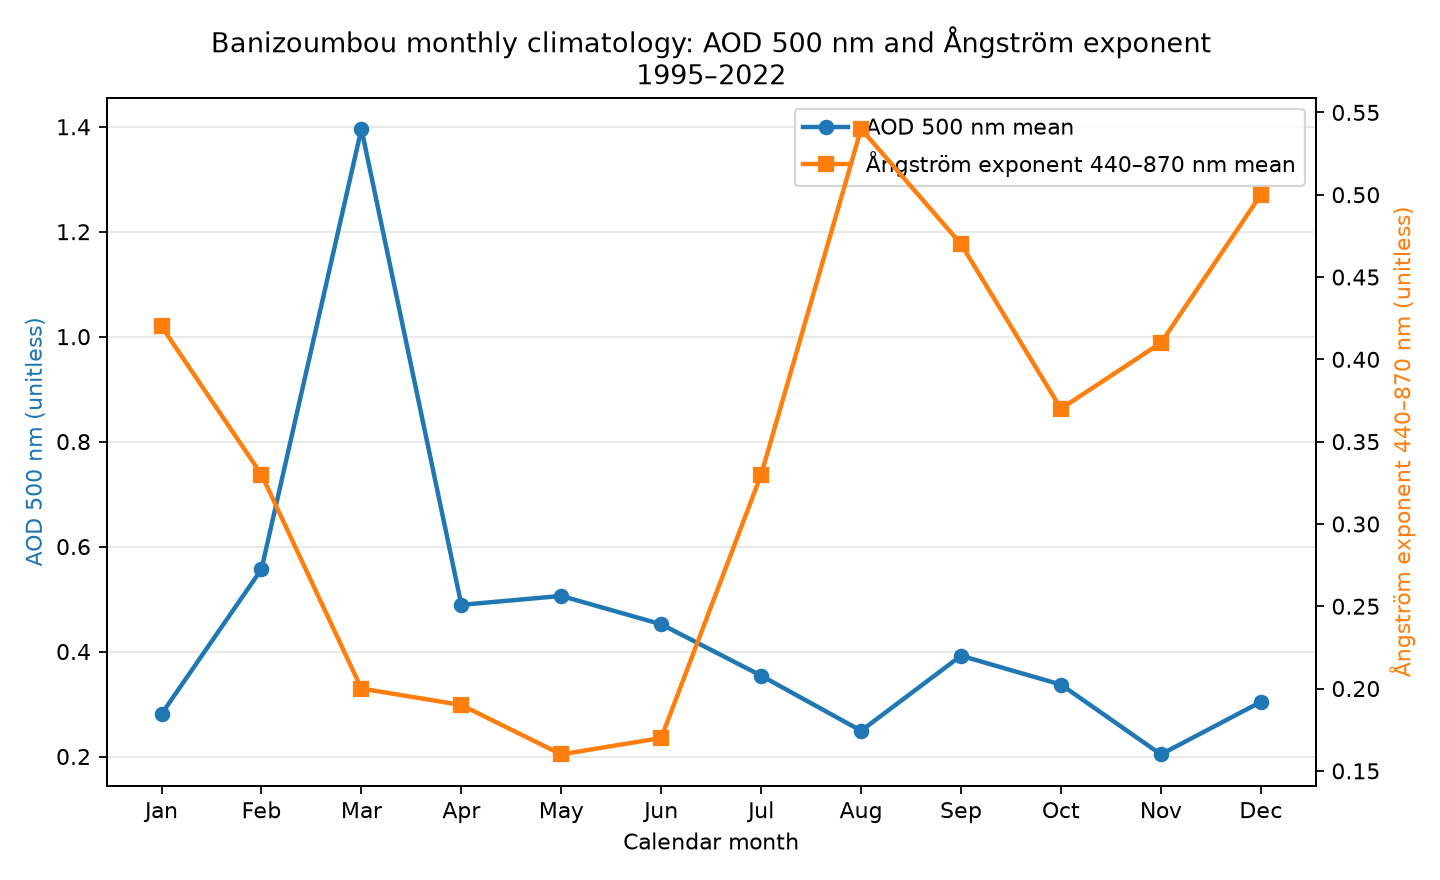


=== TURN 3 (ok): 6 model calls, 5 tool calls | in 47322 (cache read 36935, write 10375) | out 2599 (reasoning 244) | $0.0071
=== CONVERSATION : $0.0196


In [22]:
r = await ask("Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.")

In [23]:
answer(r)

Using the **climatology skill**, I calculated monthly means across all available years for **Banizoumbou** (13.547° N, 2.665° E; elevation 274 m).

| Month | Mean AOD 500 nm | AOD N (days) | AOD N (years) | Mean Ångström exponent 440–870 nm | AE SD | AE N (days) | AE N (years) |
|---|---:|---:|---:|---:|---:|---:|---:|
| Jan | 0.281 | 28 | 1 | 0.42 | 0.26 | 631 | 26 |
| Feb | 0.557 | 27 | 1 | 0.33 | 0.19 | 602 | 26 |
| Mar | 1.396 | 33 | 2 | 0.20 | 0.11 | 530 | 24 |
| Apr | 0.489 | 45 | 2 | 0.19 | 0.10 | 521 | 24 |
| May | 0.506 | 41 | 2 | 0.16 | 0.11 | 534 | 25 |
| Jun | 0.452 | 23 | 2 | 0.17 | 0.18 | 457 | 24 |
| Jul | 0.354 | 26 | 2 | 0.33 | 0.25 | 425 | 24 |
| Aug | 0.249 | 8 | 2 | 0.54 | 0.34 | 403 | 25 |
| Sep | 0.392 | 33 | 2 | 0.47 | 0.26 | 506 | 25 |
| Oct | 0.337 | 30 | 2 | 0.37 | 0.19 | 611 | 26 |
| Nov | 0.204 | 38 | 2 | 0.41 | 0.20 | 675 | 26 |
| Dec | 0.304 | 30 | 1 | 0.50 | 0.28 | 686 | 25 |

**Period and coverage**
- Site record: **1995-10-16 to 2022-11-25**
- AOD 500 nm: **N = 362 valid daily values** out of 6,581 site-days; monthly values are based on only **1–2 years** of observations.
- Ångström exponent: **N = 6,581 valid daily values**, spanning approximately **24–26 years per month**.
- Threshold: months were retained when they had at least **5 valid daily values**. All 12 months qualified.
- Method: arithmetic means of daily values grouped by calendar month. AOD variability is represented by its daily distribution; AE SD is the within-month daily standard deviation.

The AOD climatology is therefore much less robust than the AE climatology because the 500 nm channel was populated mainly in 2021–2022. The AOD 500 nm and AE measurements are not uniformly available over the same period.

Figure: **`/workspace/banizoumbou_monthly_climatology_aod500_ae440_870.png`**  
Table: **`/workspace/banizoumbou_monthly_climatology_aod500_ae440_870.csv`**

Site PI acknowledgment: **Jean_Louis_Rajot** (jeanlouis.rajot@ird.fr).

In [24]:
show_turns()

,turn,asked,status,question,summary,kernel_note,requests,tool_calls,input_tokens,cache_read,output_tokens,cost
0,1,2026-09-26T20:57:12+00:00,ok,Which five sites have the longest AOD 500 nm r...,"tools: list_sites×1, describe_columns×6, run_p...",None,5,9,42570,29868,2452,0.007386
1,2,2026-09-26T20:59:09+00:00,ok,"For the top one of those, what is its mean AOD...",tools: run_python×3 | files: mauna_loa_annual_...,None,4,3,25699,17938,1979,0.005141
2,3,2026-09-26T21:01:01+00:00,ok,Show the monthly climatology of AOD 500 nm and...,"tools: list_sites×1, describe_columns×1, run_p...",None,6,5,47322,36935,2599,0.007099


In [25]:
sb.stop(CONVERSATION_ID)      # stands in for 60 idle minutes: variables gone, files kept

In [26]:
r = await ask("What do we have so far, and what is left in the sandbox?")

=== What do we have so far, and what is left in the sandbox?
    (3 earlier turns in context; conversation so far $0.0196)

--- step 1: to model
  >>> USER        : ### sandbox state now
kernel: restarted (no reason recorded: memory limit, host restart or stopped by hand); every earlier variable is gone, files in /workspace are kept
variables: none
files in /workspace: banizoumbou_monthly_climatology_aod500_ae440_870.csv, banizoumbou_monthly_climatology_aod500_ae440_870.png, mauna_loa_annual_mean_aod500.csv, top5_aod500_records.csv
memory used: 205 MB; storage: 0 of 1000 MB

### question
What do we have so far, and what is left in the sandbox?
--- step 1: from model
  ... THINKING    : <no text>
  <<< ANSWER      : The sandbox **restarted**, so no Python variables or in-memory DataFrames remain. The files in `/workspace` survived.

### Analyses completed

1. **Five longest AOD 500 nm records**
   - Ranked all sites by the number of valid daily AOD 500 nm observations.
   - Output: **`/

In [27]:
answer(r)

The sandbox **restarted**, so no Python variables or in-memory DataFrames remain. The files in `/workspace` survived.

### Analyses completed

1. **Five longest AOD 500 nm records**
   - Ranked all sites by the number of valid daily AOD 500 nm observations.
   - Output: **`/workspace/top5_aod500_records.csv`**
   - N counted valid daily Level 2.0 AOD values; missing values were excluded, not treated as zero.

2. **Mauna_Loa annual AOD 500 nm means**
   - Site: **Mauna_Loa**, 19.536° N, −155.577° E
   - Period: **1997–2025**
   - N: **29 qualifying years**, 9,152 valid daily AOD values overall
   - Method: daily → monthly means, requiring ≥5 valid days per month; annual means requiring ≥9 valid months.
   - Output: **`/workspace/mauna_loa_annual_mean_aod500.csv`**

3. **Banizoumbou monthly climatology**
   - Site: **Banizoumbou**, 13.547° N, 2.665° E
   - Site record: **1995-10-16 to 2022-11-25**
   - Wavelengths/quantities: AOD 500 nm and Ångström exponent 440–870 nm
   - AOD: 362 valid daily values; coverage was sparse, with only 1–2 years represented per calendar month.
   - Ångström exponent: 6,581 valid daily values, with roughly 24–26 years represented per month.
   - Method: monthly arithmetic means of daily values, retaining months with ≥5 valid daily values.
   - Outputs:
     - **`/workspace/banizoumbou_monthly_climatology_aod500_ae440_870.csv`**
     - **`/workspace/banizoumbou_monthly_climatology_aod500_ae440_870.png`**

### What remains in the sandbox

- **Files:** the four files listed above.
- **Variables:** none; all previous in-memory objects were lost during the restart.
- **Plots:** only the Banizoumbou climatology plot remains.
- **Raw data:** still available at `/data/aeronet.parquet`; it is read-only and must be reloaded with selected columns for any further analysis.

The previous site-PI acknowledgments were:
- Mauna_Loa: **Pawan_Gupta_and_Elena_Lind**
- Banizoumbou: **Jean_Louis_Rajot**.

## 10 · Resume tomorrow

Nothing to save: the store already has every turn. Run sections 1–8 with the same `CONVERSATION_ID` and ask the next
question; `history_for_model()` finds the earlier turns, `ensure_running()` starts a fresh sandbox on the same
folder and tells the model the variables are gone.

In [31]:
show_turns()

,turn,asked,status,question,summary,kernel_note,requests,tool_calls,input_tokens,cache_read,output_tokens,cost
0,1,2026-09-26T20:57:12+00:00,ok,Which five sites have the longest AOD 500 nm r...,"tools: list_sites×1, describe_columns×6, run_p...",NaN,5,9,42570,29868,2452,0.007386
1,2,2026-09-26T20:59:09+00:00,ok,"For the top one of those, what is its mean AOD...",tools: run_python×3 | files: mauna_loa_annual_...,NaN,4,3,25699,17938,1979,0.005141
2,3,2026-09-26T21:01:01+00:00,ok,Show the monthly climatology of AOD 500 nm and...,"tools: list_sites×1, describe_columns×1, run_p...",NaN,6,5,47322,36935,2599,0.007099
3,4,2026-09-26T21:01:55+00:00,ok,"What do we have so far, and what is left in th...",tools: none,"restarted (no reason recorded: memory limit, h...",1,0,6569,0,684,0.002709


In [32]:
# the full trace of one turn, message by message
turn = 1
messages = ModelMessagesTypeAdapter.validate_json(
    DB.execute("SELECT messages FROM turns WHERE conversation=? AND turn=?", (CONVERSATION_ID, turn)).fetchone()[0])
for m in messages:
    for p in m.parts: show_part(p)

  >>> USER        : ### sandbox state now
variables: none
files in /workspace: none
memory used: 206 MB; storage: 0 of 1000 MB

### question
Which five sites have the longest AOD 500 nm records, and how many days of data does each have?
  ... THINKING    : <no text>
  <<< ANSWER      : I’ll first identify the longest-record sites, then verify that each has AOD 500 nm coverage before counting valid AOD 500 nm days.
  --> TOOL CALL   : list_sites({"limit":10})
  <-- TOOL RESULT : list_sites -> 1485 site(s) match, showing the 10 with the longest records
                      lat      lon  elev_m       first        last  days
AERONET_Site_Name                                                       
Mauna_Loa          19.536 -155.577    3402  1994-06-03  2026-07-07  9198
GSFC               38.992  -76.840      87  1993-05-14  2026-01-08  8234
SEDE_BOKER         30.855   34.782     480  1995-08-11  2025-04-04  7767
Ispra              45.803    8.627     235  1997-06-28  2026-03-12  6766
Baniz

## 11 · Cleanup

In [33]:
sb.stop(CONVERSATION_ID)